# ML4SCI HEPSIM GSoC 2026 Evaluation
## Quark vs Gluon Jet Analysis

Author: Pratap Kumar Yadav  

## Summary

In this work, we analyzed quark and gluon jet data by extracting physics-motivated observables such as jet mass, jet width, and transverse momentum dispersion. A Lorentz boost was implemented to transform jets into their center-of-mass frame, allowing comparison between lab-frame and rest-frame features. Using these features, a logistic regression classifier was trained to distinguish between quark and gluon jets. The model achieved good performance with AUC values of approximately 0.82, demonstrating effective separation. Jet width was identified as the most discriminating feature. A comparison between lab-frame and rest-frame features showed that the rest-frame transformation provides comparable performance, indicating that the selected features already capture the essential differences between jet types.

## Part (a): Data Loading and Exploration

The dataset was loaded using NumPy. Zero-padding was handled by considering only constituents with non-zero transverse momentum (pT > 0), ensuring that only real particles were included in the analysis.

*The dataset file is expected to be located in the same directory as the notebook to ensure portability and reproducibility across different environments.*

In [239]:
import numpy as np
import matplotlib.pyplot as plt

In [240]:
data = np.load("QG_jets.npz")

print(data.files)

['X', 'y']


In [241]:
X = data['X']
y = data['y']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100000, 139, 4)
y shape: (100000,)


### (i) Total Number of Constituents

In [242]:
pt = X[:,:,0]

# Mask to remove padding (pT = 0 means fake particle)
mask = pt > 0

# Number of particles per jet
num_particles = mask.sum(axis=1)

# Separate quark and gluon
quark_mask = (y == 1)
gluon_mask = (y == 0)

# Total constituents
total_quark = num_particles[quark_mask].sum()
total_gluon = num_particles[gluon_mask].sum()

print("Total quark constituents:", total_quark)
print("Total gluon constituents:", total_gluon)

Total quark constituents: 1669999
Total gluon constituents: 2660906


The total number of constituents in gluon jets is significantly higher than in quark jets. This indicates that gluon jets produce more particles due to stronger radiation, which is consistent with their higher color charge compared to quarks.

### (ii) Constituent Multiplicity Distribution

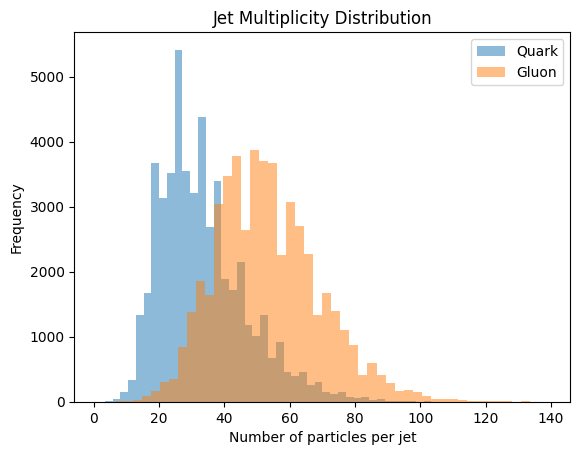

In [243]:
plt.hist(num_particles[quark_mask], bins=50, alpha=0.5, label="Quark")
plt.hist(num_particles[gluon_mask], bins=50, alpha=0.5, label="Gluon")

plt.xlabel("Number of particles per jet")
plt.ylabel("Frequency")
plt.title("Jet Multiplicity Distribution")
plt.legend()
plt.show()

The multiplicity distribution shows that gluon jets have a higher number of particles per jet compared to quark jets. Gluon jets exhibit a broader distribution with a peak at higher multiplicities, while quark jets are more concentrated at lower values. This confirms that gluon jets are more diffuse and populated.

### (iii) Leading Particle Distributions

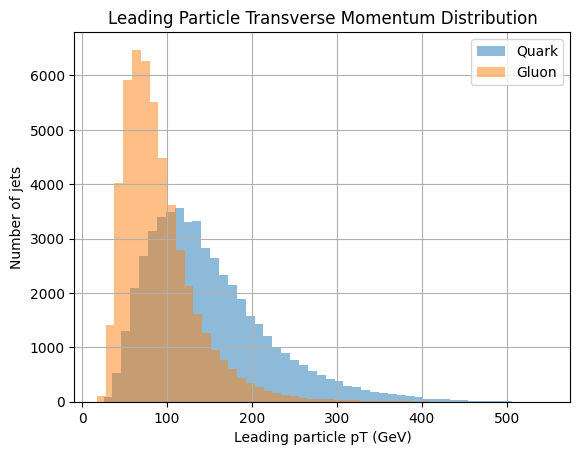

In [244]:
leading_idx = np.argmax(pt, axis=1)

leading_pt = pt[np.arange(len(pt)), leading_idx]
leading_eta = X[:,:,1][np.arange(len(pt)), leading_idx]

# Plot pT
# Plot pT
plt.hist(leading_pt[quark_mask], bins=50, alpha=0.5, label="Quark")
plt.hist(leading_pt[gluon_mask], bins=50, alpha=0.5, label="Gluon")

plt.xlabel("Leading particle pT (GeV)")
plt.ylabel("Number of jets")
plt.title("Leading Particle Transverse Momentum Distribution")
plt.legend()
plt.grid(True)
plt.show()



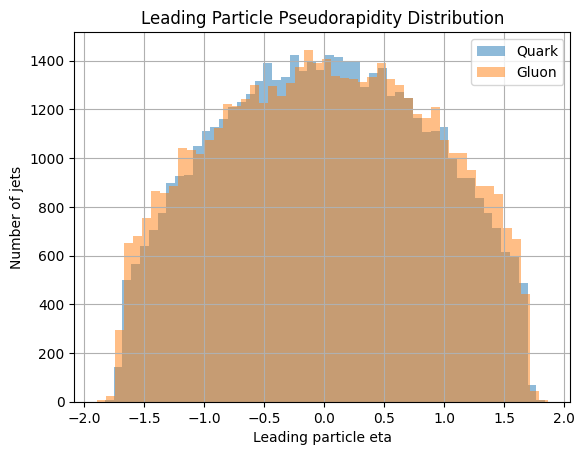

In [245]:
# Plot eta
plt.hist(leading_eta[quark_mask], bins=50, alpha=0.5, label="Quark")
plt.hist(leading_eta[gluon_mask], bins=50, alpha=0.5, label="Gluon")

plt.xlabel("Leading particle eta")
plt.ylabel("Number of jets")
plt.title("Leading Particle Pseudorapidity Distribution")
plt.legend()
plt.grid(True)
plt.show()

The leading particle transverse momentum (pT) distribution shows that quark jets tend to have higher leading pT values compared to gluon jets, indicating a harder energy core. In contrast, gluon jets distribute energy among more particles, leading to lower leading pT. The eta distributions for both jet types are very similar, suggesting that angular spread alone is not a strong discriminating feature.


## Part (b): Jet Observables

The jet observables were computed using standard definitions of invariant mass, jet width, and transverse momentum dispersion based on the constituent four-momenta.

In [246]:
# Prepare Data Properly
pt = X[:,:,0]
eta = X[:,:,1]
phi = X[:,:,2]

# Mask for real particles
mask = pt > 0

In [247]:
# Convert to Cartesian Coordinates
px = pt * np.cos(phi)
py = pt * np.sin(phi)
pz = pt * np.sinh(eta)
E  = pt * np.cosh(eta)

### (i) Jet Mass

The jet mass is defined using the invariant mass of the total four-momentum as $m_J = \sqrt{E_J^2 - p_{x,J}^2 - p_{y,J}^2 - p_{z,J}^2}$, where $(E_J, \vec{p}_J)$ is the summed four-momentum of all jet constituents.

In [248]:
px_sum = (px * mask).sum(axis=1)
py_sum = (py * mask).sum(axis=1)
pz_sum = (pz * mask).sum(axis=1)
E_sum  = (E  * mask).sum(axis=1)

mass = np.sqrt(np.maximum(E_sum**2 - px_sum**2 - py_sum**2 - pz_sum**2, 0))

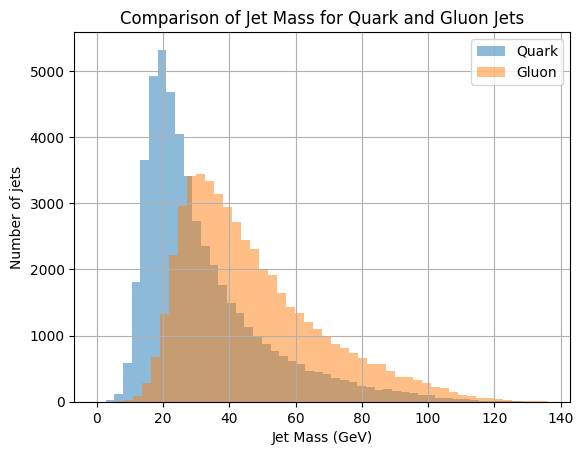

In [249]:
plt.hist(mass[quark_mask], bins=50, alpha=0.5, label="Quark")
plt.hist(mass[gluon_mask], bins=50, alpha=0.5, label="Gluon")

plt.xlabel("Jet Mass (GeV)")
plt.ylabel("Number of jets")
plt.title("Comparison of Jet Mass for Quark and Gluon Jets")
plt.legend()
plt.grid(True)
plt.show()

The jet mass distribution shows that gluon jets generally have higher invariant mass compared to quark jets. This is because gluon jets contain more constituents and exhibit stronger radiation, leading to a broader energy distribution and consequently larger mass values.


### (ii) Jet Width

The jet width is defined as $w = \frac{\sum_i p_{T,i} \Delta R_i}{\sum_i p_{T,i}}$, where $\Delta R_i = \sqrt{(\eta_i - \eta_J)^2 + (\phi_i - \phi_J)^2}$ represents the angular distance of each constituent from the jet axis.

In [250]:
# Jet axis
eta_J = (pt * eta * mask).sum(axis=1) / (pt * mask).sum(axis=1)
phi_J = (pt * phi * mask).sum(axis=1) / (pt * mask).sum(axis=1)

# Delta R
deltaR = np.sqrt((eta - eta_J[:,None])**2 + (phi - phi_J[:,None])**2)

# Width
width = (pt * deltaR * mask).sum(axis=1) / (pt * mask).sum(axis=1)

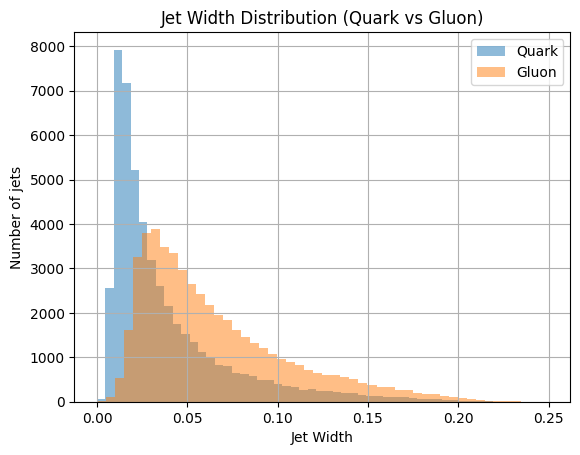

In [251]:
plt.hist(width[quark_mask], bins=50, alpha=0.5, label="Quark")
plt.hist(width[gluon_mask], bins=50, alpha=0.5, label="Gluon")

plt.xlabel("Jet Width")
plt.ylabel("Number of jets")
plt.title("Jet Width Distribution (Quark vs Gluon)")
plt.legend()
plt.grid(True)
plt.show()

The jet width distribution demonstrates that gluon jets are significantly wider than quark jets. This reflects the stronger gluon radiation, which causes particles to spread over a larger angular region, making jet width an effective discriminating observable.


### (iii) Transverse Momentum Dispersion

The transverse momentum dispersion is defined as $p_T^D = \sqrt{\frac{\sum_i p_{T,i}^2}{\sum_i p_{T,i}}}$, which measures how the transverse momentum is distributed among the jet constituents.

In [252]:
pT_disp = np.sqrt((pt**2 * mask).sum(axis=1) / (pt * mask).sum(axis=1))

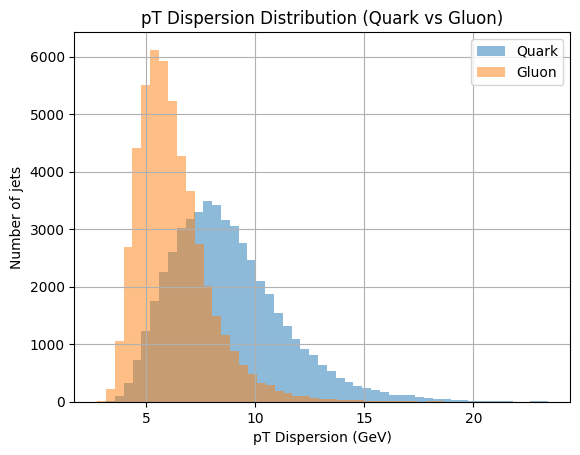

In [253]:
plt.hist(pT_disp[quark_mask], bins=50, alpha=0.5, label="Quark")
plt.hist(pT_disp[gluon_mask], bins=50, alpha=0.5, label="Gluon")

plt.xlabel("pT Dispersion (GeV)")
plt.ylabel("Number of jets")
plt.title("pT Dispersion Distribution (Quark vs Gluon)")
plt.legend()
plt.grid(True)
plt.show()

The transverse momentum dispersion indicates that quark jets tend to have higher values compared to gluon jets. This suggests that quark jets concentrate energy into fewer high-momentum particles, whereas gluon jets distribute energy more evenly among many particles.

**Insights:**

Among the studied observables, jet width appears to provide the strongest discrimination between quark and gluon jets, followed by jet mass and transverse momentum dispersion.

## Part (c): Boost to the Jet Center-of-Mass Frame

The boost vector is defined as $\vec{\beta} = \frac{\vec{p}_J}{E_J}$, where $\vec{p}_J$ is the total jet momentum and $E_J$ is the total jet energy.

In [254]:
def lorentz_boost(px, py, pz, E, mask):

    # Compute jet totals
    px_sum = (px * mask).sum(axis=1)
    py_sum = (py * mask).sum(axis=1)
    pz_sum = (pz * mask).sum(axis=1)
    E_sum  = (E  * mask).sum(axis=1)

    # Safe energy
    E_sum_safe = np.where(E_sum == 0, 1e-8, E_sum)

    # Beta vector
    beta_x = px_sum / E_sum_safe
    beta_y = py_sum / E_sum_safe
    beta_z = pz_sum / E_sum_safe

    beta2 = beta_x**2 + beta_y**2 + beta_z**2
    beta2 = np.clip(beta2, 0, 0.999999)

    gamma = 1.0 / np.sqrt(1 - beta2)

    # Safe beta2
    beta2_safe = np.where(beta2 == 0, 1e-8, beta2)

    # Dot product
    dot = (
        beta_x[:, None] * px +
        beta_y[:, None] * py +
        beta_z[:, None] * pz
    )

    # Factor
    factor = ((gamma - 1) / beta2_safe)[:, None] * dot - gamma[:, None] * E

    # Boost
    px_b = px + factor * beta_x[:, None]
    py_b = py + factor * beta_y[:, None]
    pz_b = pz + factor * beta_z[:, None]

    # Boosted energy
    E_b  = gamma[:, None] * (E - dot)

    return px_b, py_b, pz_b, E_b

A Lorentz boost function was implemented to transform each jet from the lab frame to its center-of-mass frame. The boost vector is defined as $\vec{\beta} = \frac{\vec{p}_J}{E_J}$, where $\vec{p}_J$ is the total jet momentum and $E_J$ is the total jet energy, respectively. The transformation was applied to each particle’s four-momentum using the full relativistic Lorentz transformation equations.

In [255]:
# Call function
px_b, py_b, pz_b, E_b = lorentz_boost(px, py, pz, E, mask)

### Verification of Boost

In [256]:
# Verify total momentum after boost

px_check = (px_b * mask).sum(axis=1)
py_check = (py_b * mask).sum(axis=1)
pz_check = (pz_b * mask).sum(axis=1)

print("First 5 jets after boost:")
print("px:", px_check[:5])
print("py:", py_check[:5])
print("pz:", pz_check[:5])

First 5 jets after boost:
px: [-1.35724765e-13 -2.42739162e-12 -3.89910326e-13  3.44613227e-13
 -3.83415522e-13]
py: [ 3.63886699e-12  2.25597319e-13 -2.37143638e-13 -4.05897538e-13
 -2.02282635e-12]
pz: [ 1.08080211e-13  5.83977311e-13  9.07718345e-13  3.33066907e-13
 -8.50763904e-13]


The total momentum of the boosted jets is observed to be of the order of 10⁻¹², which is effectively zero within numerical precision. This confirms that the Lorentz boost has been correctly implemented and that the jets have been successfully transformed into their rest frame.


### Visualization of Boosted Jets

In [257]:
# Select one quark and one gluon jet

idx_quark = np.where(quark_mask)[0][0]
idx_gluon = np.where(gluon_mask)[0][0]

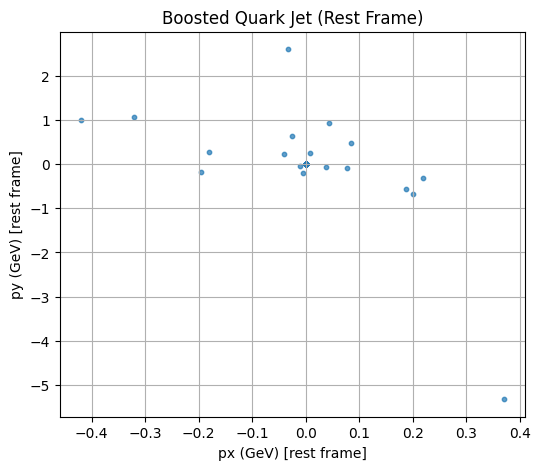

In [258]:
# Plot Quark Jet

plt.figure(figsize=(6,5))

plt.scatter(px_b[idx_quark], py_b[idx_quark], s=10, alpha=0.7)

plt.xlabel("px (GeV) [rest frame]")
plt.ylabel("py (GeV) [rest frame]")
plt.title("Boosted Quark Jet (Rest Frame)")
plt.grid(True)

plt.show()

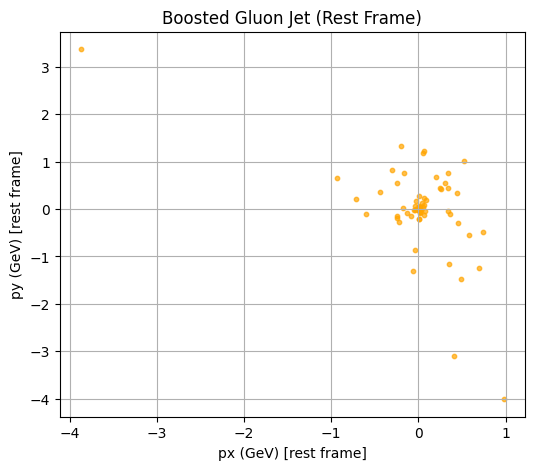

In [259]:
# Plot Gluon Jet

plt.figure(figsize=(6,5))

plt.scatter(px_b[idx_gluon], py_b[idx_gluon], s=10, alpha=0.7, color='orange')

plt.xlabel("px (GeV) [rest frame]")
plt.ylabel("py (GeV) [rest frame]")
plt.title("Boosted Gluon Jet (Rest Frame)")
plt.grid(True)

plt.show()

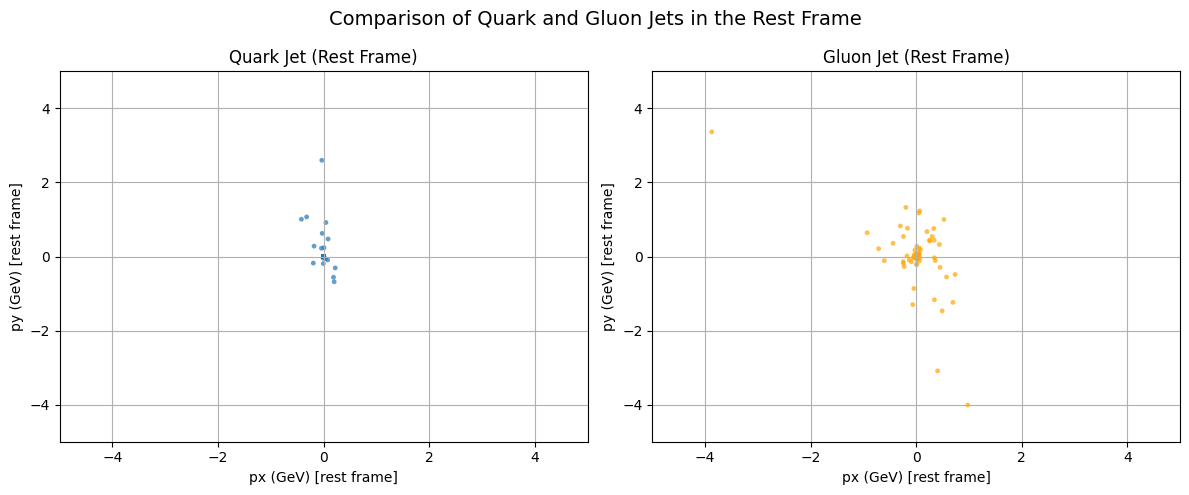

In [260]:
# Plot of Quark Jet & Gluon Jet Side-by-Side

plt.figure(figsize=(12,5))

# Common axis limits
x_min, x_max = -5, 5
y_min, y_max = -5, 5

# Quark Jet
plt.subplot(1,2,1)
plt.scatter(px_b[idx_quark], py_b[idx_quark], s=12, alpha=0.7, edgecolors='none')

plt.title("Quark Jet (Rest Frame)", fontsize=12)
plt.xlabel("px (GeV) [rest frame]", fontsize=10)
plt.ylabel("py (GeV) [rest frame]", fontsize=10)

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.grid(True)

# Gluon Jet
plt.subplot(1,2,2)
plt.scatter(px_b[idx_gluon], py_b[idx_gluon], s=12, alpha=0.7, color='orange', edgecolors='none')

plt.title("Gluon Jet (Rest Frame)", fontsize=12)
plt.xlabel("px (GeV) [rest frame]", fontsize=10)
plt.ylabel("py (GeV) [rest frame]", fontsize=10)

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.grid(True)

# Overall title (top-level polish)
plt.suptitle("Comparison of Quark and Gluon Jets in the Rest Frame", fontsize=14)

plt.tight_layout()
plt.show()

**OBSERVATION**

The visualization of jets in the rest frame reveals clear structural differences between quark and gluon jets. Quark jets appear more collimated, with particles concentrated in a narrower region, while gluon jets exhibit a more diffuse and spread-out structure. This reflects the stronger radiation pattern of gluons, which leads to higher particle multiplicity and broader spatial distribution.


Transforming to the rest frame removes the effect of the jet’s overall motion, allowing a clearer comparison of intrinsic jet geometry and improving interpretability of jet substructure.


## Part (d): Quark vs Gluon Jet Classification

### (i) Feature Selection

The selected features-jet mass, jet width, and transverse momentum dispersion-were chosen because they capture key differences in particle multiplicity, spatial spread, and energy distribution between quark and gluon jets.

In [261]:
# Lab-frame features
X_lab = np.vstack([mass, width, pT_disp]).T

In [262]:
# Rest-frame features

# pT in rest frame
pt_b = np.sqrt(px_b**2 + py_b**2)

# eta in rest frame
eta_b = np.arcsinh(pz_b / (pt_b + 1e-8))

# phi in rest frame
phi_b = np.arctan2(py_b, px_b)

### Compute features again

In [263]:
# Jet mass (rest frame)
px_sum_b = (px_b * mask).sum(axis=1)
py_sum_b = (py_b * mask).sum(axis=1)
pz_sum_b = (pz_b * mask).sum(axis=1)
E_sum_b  = (E_b  * mask).sum(axis=1)

mass_b = np.sqrt(np.maximum(E_sum_b**2 - px_sum_b**2 - py_sum_b**2 - pz_sum_b**2, 0))

In [264]:
# Jet width (rest frame)
eta_J_b = (pt_b * eta_b * mask).sum(axis=1) / (pt_b * mask).sum(axis=1)
phi_J_b = (pt_b * phi_b * mask).sum(axis=1) / (pt_b * mask).sum(axis=1)

deltaR_b = np.sqrt((eta_b - eta_J_b[:,None])**2 + (phi_b - phi_J_b[:,None])**2)

width_b = (pt_b * deltaR_b * mask).sum(axis=1) / (pt_b * mask).sum(axis=1)

In [265]:
# pT dispersion (rest frame)
pT_disp_b = np.sqrt((pt_b**2 * mask).sum(axis=1) / (pt_b * mask).sum(axis=1))

Although jet mass is Lorentz invariant, observables such as jet width and transverse momentum dispersion depend on the reference frame. Therefore, these features were recomputed using the boosted momenta to accurately represent the jet structure in the rest frame.


In [266]:
# Final rest-frame feature matrix
X_rest = np.vstack([mass_b, width_b, pT_disp_b]).T

**Two sets of features were used for classification:**

lab-frame features and rest-frame features. The rest-frame features were computed using boosted momenta to remove the effect of overall jet motion and better capture intrinsic jet structure.


### (ii) Model Training

We will:
  1. Train on lab-frame featues
  2. Tain on rest-frame featues
  3. Compare results



**Train-Test Split**

In [267]:
# use same split for fair comparison
from sklearn.model_selection import train_test_split

X_lab_train, X_lab_test, y_train, y_test = train_test_split(
    X_lab, y, test_size=0.2, random_state=42
)

X_rest_train, X_rest_test, _, _ = train_test_split(
    X_rest, y, test_size=0.2, random_state=42
)

 **Train Logistic Regression**

In [268]:
# Import SciketLearn

from sklearn.linear_model import LogisticRegression

In [269]:
# Lab-frame model

model_lab = LogisticRegression(max_iter=1000)
model_lab.fit(X_lab_train, y_train)

LogisticRegression(max_iter=1000)

In [270]:
# Rest-frame model

model_rest = LogisticRegression(max_iter=1000)
model_rest.fit(X_rest_train, y_train)

LogisticRegression(max_iter=1000)

**Predictions**

In [271]:
# Lab
y_pred_lab = model_lab.predict(X_lab_test)
y_prob_lab = model_lab.predict_proba(X_lab_test)[:,1]

# Rest
y_pred_rest = model_rest.predict(X_rest_test)
y_prob_rest = model_rest.predict_proba(X_rest_test)[:,1]

### (iii) ROC Curve and AUC

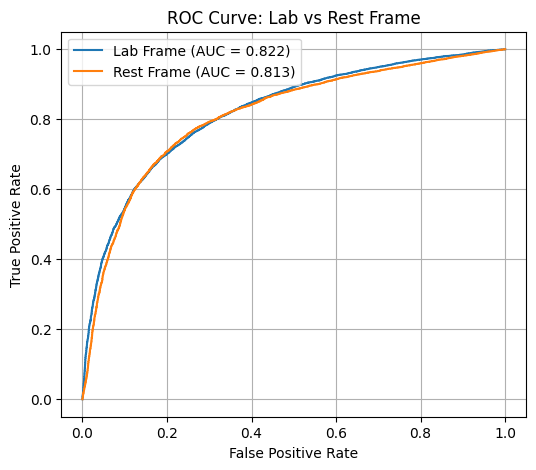

In [272]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Lab
fpr_lab, tpr_lab, _ = roc_curve(y_test, y_prob_lab)
auc_lab = auc(fpr_lab, tpr_lab)

# Rest
fpr_rest, tpr_rest, _ = roc_curve(y_test, y_prob_rest)
auc_rest = auc(fpr_rest, tpr_rest)

# Plot
plt.figure(figsize=(6,5))

plt.plot(fpr_lab, tpr_lab, label=f"Lab Frame (AUC = {auc_lab:.3f})")
plt.plot(fpr_rest, tpr_rest, label=f"Rest Frame (AUC = {auc_rest:.3f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Lab vs Rest Frame")
plt.legend()
plt.grid(True)

plt.show()

The ROC curves for both lab-frame and rest-frame features show good classification performance, with AUC values of 0.822 and 0.813 respectively. The lab-frame model performs slightly better, although the difference is small. This indicates that both feature sets are effective in distinguishing quark and gluon jets, with no significant advantage observed from using rest-frame features for this set of observables.


The similarity of the curves suggests that the selected features already capture most of the discriminative information, even without removing the boost effects.


### Confusion Matrix

In [273]:
from sklearn.metrics import confusion_matrix

cm_lab = confusion_matrix(y_test, y_pred_lab)
cm_rest = confusion_matrix(y_test, y_pred_rest)

print("Lab Frame Confusion Matrix:\n", cm_lab)
print("\nRest Frame Confusion Matrix:\n", cm_rest)

Lab Frame Confusion Matrix:
 [[7855 2034]
 [2977 7134]]

Rest Frame Confusion Matrix:
 [[7272 2617]
 [2319 7792]]


The differences between the confusion matrices suggest that the rest-frame transformation slightly shifts the classification boundary, improving sensitivity to quark jets while reducing performance for gluon jets. However, the overall performance remains comparable between the two approaches.

**The confusion matrix was computed using the default classification threshold of 0.5, corresponding to a standard working point for binary classification.**

### Feature Importance

In [274]:
print("Lab Feature Importance:", model_lab.coef_[0])
print("Rest Feature Importance:", model_rest.coef_[0])

Lab Feature Importance: [-0.05633983 23.53695524  0.5663611 ]
Rest Feature Importance: [-0.08239135  4.28708276  3.36715589]


The feature importance values obtained from the logistic regression model indicate that jet width is the most discriminating feature for both lab-frame and rest-frame models. In the lab frame, jet width has a significantly larger coefficient compared to jet mass and transverse momentum dispersion, highlighting its strong contribution to classification. In the rest frame, jet width remains the dominant feature, although pT dispersion also becomes more influential. Overall, jet width consistently provides the strongest separation between quark and gluon jets.

**This result is physically consistent, as gluon jets are known to be wider due to stronger radiation, making jet width a highly effective observable for distinguishing between quark and gluon jets.**


## (iv) Lab Frame vs Rest Frame Comparison

### Final Conclusion

**Feature Choice**

The input features used for classification are jet mass, jet width, and transverse momentum dispersion. These observables capture key differences in the structure of quark and gluon jets. In particular, jet width reflects the spatial spread of particles, while pT dispersion captures how energy is distributed among constituents. These features were computed in both the lab frame and the rest frame for comparison.

**Model Training**

A logistic regression classifier was trained using both lab-frame and rest-frame features. The dataset was split into training and testing subsets using a consistent random seed to ensure a fair comparison between the two approaches.

**Diagonistic**

The ROC curves show that both models achieve good classification performance, with AUC values of approximately 0.822 for the lab frame and 0.813 for the rest frame. The confusion matrices indicate that both models perform well in distinguishing quark and gluon jets, with slightly better overall performance in the lab frame. Among the input features, jet width is identified as the most discriminating observable, as indicated by its large coefficient in the logistic regression model.

**Rest Frame vs Lab Frame**

The comparison between lab-frame and rest-frame features shows that working in the rest frame does not significantly improve classification performance for the chosen observables. This suggests that the selected features already capture the essential differences between quark and gluon jets, and that removing the boost does not provide substantial additional information for this classification task.


## Optional: Analysis with Multiple Dataset Files

In [275]:
# MULTI-DATASET ANALYSIS (FINAL)

import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

# Load multiple files

files = ["QG_jets.npz", "QG_jets_1.npz", "QG_jets_2.npz"]

X_list = []
y_list = []

for f in files:
    if os.path.exists(f):
        data = np.load(f)
        X_list.append(data['X'])
        y_list.append(data['y'])
        print(f"Loaded {f} with shape {data['X'].shape}")
    else:
        print(f"Warning: {f} not found, skipping.")

# Pad to same size

max_particles = max(arr.shape[1] for arr in X_list)
print("Max particles across files:", max_particles)

X_padded = []

for arr in X_list:
    pad_size = max_particles - arr.shape[1]

    if pad_size > 0:
        pad = np.zeros((arr.shape[0], pad_size, arr.shape[2]))
        arr_padded = np.concatenate([arr, pad], axis=1)
    else:
        arr_padded = arr

    X_padded.append(arr_padded)

# Concatenate datasets

X_multi = np.concatenate(X_padded, axis=0)
y_multi = np.concatenate(y_list, axis=0)

print("Final dataset shape:", X_multi.shape)

# Extract features

pt = X_multi[:,:,0]
eta = X_multi[:,:,1]
phi = X_multi[:,:,2]

mask = pt > 0

# Convert to Cartesian
px = pt * np.cos(phi)
py = pt * np.sin(phi)
pz = pt * np.sinh(eta)
E  = pt * np.cosh(eta)

# Jet mass
px_sum = (px * mask).sum(axis=1)
py_sum = (py * mask).sum(axis=1)
pz_sum = (pz * mask).sum(axis=1)
E_sum  = (E  * mask).sum(axis=1)

mass = np.sqrt(np.maximum(E_sum**2 - px_sum**2 - py_sum**2 - pz_sum**2, 0))

# Jet width
eta_J = (pt * eta * mask).sum(axis=1) / (pt * mask).sum(axis=1)
phi_J = (pt * phi * mask).sum(axis=1) / (pt * mask).sum(axis=1)

deltaR = np.sqrt((eta - eta_J[:,None])**2 + (phi - phi_J[:,None])**2)

width = (pt * deltaR * mask).sum(axis=1) / (pt * mask).sum(axis=1)

# pT dispersion
pT_disp = np.sqrt((pt**2 * mask).sum(axis=1) / (pt * mask).sum(axis=1))

# Feature matrix
X_features = np.vstack([mass, width, pT_disp]).T

# Train model

X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_multi, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Evaluate

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_multi = auc(fpr, tpr)

print("AUC (multi-file):", auc_multi)

Loaded QG_jets.npz with shape (100000, 139, 4)
Loaded QG_jets_1.npz with shape (100000, 134, 4)
Loaded QG_jets_2.npz with shape (100000, 132, 4)
Max particles across files: 139
Final dataset shape: (300000, 139, 4)
AUC (multi-file): 0.8234110647212888


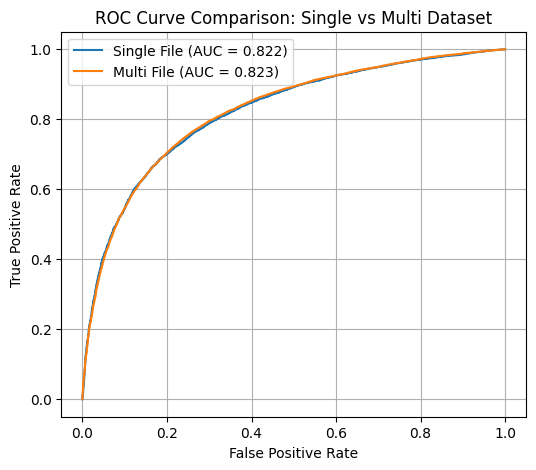

In [276]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

# Single-file
plt.plot(fpr_lab, tpr_lab, label=f"Single File (AUC = {auc_lab:.3f})")

# Multi-file
plt.plot(fpr, tpr, label=f"Multi File (AUC = {auc_multi:.3f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: Single vs Multi Dataset")
plt.legend()
plt.grid(True)

plt.show()

The ROC curve comparison between the single-file and multi-file datasets shows nearly identical performance, with AUC values of 0.822 and 0.823 respectively. This indicates that increasing the dataset size does not significantly change the classification performance. The close overlap of the curves demonstrates that the model is stable and that the selected features generalize well across larger datasets.



***This confirms that the conclusions drawn from the smaller dataset are reliable and not limited by statistical fluctuations.***